# Step 2 — Calibration and out-of-sample forecast evaluation

**MSc dissertation, causal inference in USDJPY volatility.** Supervisor: Linus Too.
Implements **Exercise 2** of *Implied Vol Event Time Series* (Linus Too, 6 Aug 2026):

> *"Calibrate the models to the implied volatility and spot log-return time series data.
> Measure the forecasting accuracy of the model using out-of-sample data."*

## What Step 1 handed over, and what is not re-opened here

Step 1 identified the causal structure of the three-state system and froze four decisions.
This notebook **inherits** them; it does not re-litigate them.

| Decision | Value | Where it was settled |
|---|---|---|
| IV alignment | **next-day** — $\sigma^2_t$ paired with $\tilde\sigma^2_{t+1}$ | Step 1 §3/§7, lead–lag profile peaks at $h=+1$ (0.557 vs 0.520 same-day) |
| Lag order | **$n=m=1$** (one model day) primary; $p=5$ secondary robustness only | Step 1 §5, hand-chosen; no AIC/BIC search |
| Retained arrows | `iv_var→r2`, `iv_var→rv`, `r2→iv_var`, `rv→iv_var`, `rv→r2` | Step 1 §8, BH-FDR under *both* Granger and TDMI |
| Rejected arrow | `r2→rv` | as above |

The single structural consequence for calibration is that **the $r^2$ block leaves the
realised-variance equation**. So the two equations to calibrate are

$$\textbf{Eq 2 (restricted)}\qquad \tilde\sigma_i^2 \;=\; \tilde\phi \;+\; \tilde\beta_1\,\tilde\sigma_{i-1}^2 \;+\; \tilde\gamma_1\,\sigma_{i-1}^2 \;+\; \tilde\nu_i\eta_i$$

$$\textbf{Eq 3 (restricted)}\qquad \sigma_i^2 \;=\; \phi \;+\; \alpha_1 r_{i-1}^2 \;+\; \beta_1\,\tilde\sigma_{i-1}^2 \;+\; \gamma_1\,\sigma_{i-1}^2 \;+\; \nu_i\zeta_i$$

**Note immediately** — and this shapes how the results below must be read — Step 1 retained
*all three* blocks in Eq 3. The restricted Eq 3 and the unrestricted Eq 3 are therefore the
**same model**. The "does the causal restriction earn its keep out-of-sample?" question is
substantive for **Eq 2 only**; for Eq 3 the honest answer is that Step 1 imposed no
restriction to test, and the comparison that carries information there is against the naive
baselines. We report this rather than quietly presenting an identical pair of rows as if it
were a finding.

## Equation 1 is not calibrated

$$r_i = \mu_i + \tilde\sigma_i\epsilon_i$$

has nothing latent in it on our data: $\tilde\sigma_i$ **is observed** — it is $\sqrt{\texttt{rv}}$.
There is no volatility state to filter and no forecasting model to build. The only open
question is whether $\mu_i\approx 0$ is a defensible simplification, which is a one-line
$t$-test (§3). We do that and move on.

## Road map

| § | Content |
|---|---|
| 1 | Load Step 1's exported panel; build the model frame; chronological train/test split |
| 2 | ADF stationarity, **re-run independently** on this notebook's own data load |
| 3 | Equation 1: is $\mu_i \approx 0$? |
| 4 | OLS calibration of Eq 2 / Eq 3 (why OLS is the MLE here, not a default) |
| 5 | Residual diagnostics — Ljung–Box, ARCH-LM, the 5-lag weekly cycle; verdict on $\tilde\nu_i,\nu_i$ |
| 6 | Robustness: weekday-normalised implied variance (train-only scaling) |
| 7 | Out-of-sample evaluation — RMSE / MAE / QLIKE against four models, with Diebold–Mariano |
| 8 | Secondary robustness: $p=5$ |
| 9 | Verdicts and limitations |

---
# 1. Inputs, model frame, and the split

## 1.1 We consume Step 1's panel, we do not rebuild it

Step 1 now exports `step1_results/step1_panel.csv` — the *exact* daily panel its tests ran on,
including the RV-eligibility flags, the raw and next-day-shifted implied-variance columns, and
the calendar-contiguity flag. Step 2 loads that file.

The alternative — re-deriving the panel from the raw hourly returns and the ATM quote file —
would reintroduce every construction decision Step 1 made (the 17:00 NY cut, the 24-bar
eligibility rule, the zero-RV holiday exclusion, the no-shift-across-the-2010-outage mask) as a
fresh opportunity to differ by one row. A silent mismatch there would invalidate the whole
premise that Step 2 is calibrating the structure Step 1 tested. Loading the artifact makes that
class of error impossible rather than merely unlikely.

In [1]:
from pathlib import Path
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from IPython.display import display, Markdown

IN_DIR  = Path("step1_results")
PANEL_CSV, STRUCT_JSON = IN_DIR / "step1_panel.csv", IN_DIR / "step1_structure.json"
OUT_DIR = Path("step2_results"); OUT_DIR.mkdir(exist_ok=True)
for p in (PANEL_CSV, STRUCT_JSON):
    if not p.exists(): raise FileNotFoundError(f"Step 1 artifact missing: {p} — run Step 1 first")

# ---- frozen constants (inherited; none of these is re-chosen here) ---------
MAX_CAL_GAP = 7      # a lag window may not span a calendar gap wider than this (days)
P_PRIMARY   = 1      # n = m = 1, per Step 1
P_SECONDARY = 5      # labelled robustness only — never co-primary
TEST_FRAC   = 0.20   # most recent 20% held out
ALPHA       = 0.05
LB_LAGS     = [5, 10, 20]
ARCH_LAGS   = 12

# ---- styling: identical palette to Step 1 (validated, slots 1-3) -----------
SERIES = {"r2": "#2a78d6", "rv": "#eb6834", "iv": "#1baf7a"}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "grid.color": GRID,
    "axes.grid": True, "grid.linewidth": 0.6, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 9, "figure.dpi": 110,
})
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)

# ---- load ------------------------------------------------------------------
panel = pd.read_csv(PANEL_CSV, parse_dates=["model_day"])
structure = json.loads(STRUCT_JSON.read_text())

assert panel.model_day.is_monotonic_increasing and panel.model_day.is_unique
assert structure["adopted_alignment"] == "nextday" and structure["adopted_lag_order"] == 1, \
    "Step 1 artifact does not carry the frozen decisions this notebook assumes"

print(f"panel      : {len(panel):,} model days, {panel.model_day.min().date()} .. {panel.model_day.max().date()}")
print(f"structure  : alignment={structure['adopted_alignment']}, lag={structure['adopted_lag_order']}")
print(f"  retained : {', '.join(structure['retained_arrows'])}")
print(f"  rejected : {', '.join(structure['rejected_arrows'])}")
print(f"  Eq2 blocks kept: {structure['eq2_blocks_retained']}   dropped: {structure['eq2_blocks_dropped']}")
print(f"  Eq3 blocks kept: {structure['eq3_blocks_retained']}")

panel      : 5,842 model days, 2003-05-05 .. 2026-07-02
structure  : alignment=nextday, lag=1
  retained : iv_var -> r2, iv_var -> rv, r2 -> iv_var, rv -> iv_var, rv -> r2
  rejected : r2 -> rv
  Eq2 blocks kept: ['rv_lag', 'iv_lag']   dropped: ['r2_lag']
  Eq3 blocks kept: ['r2_lag', 'rv_lag', 'iv_lag']


## 1.2 The model frame, the contiguity guard, and one shared estimation sample

`iv` in this notebook is Step 1's **`iv_nextday`** column: the quote observed on model day
$t-1$, sitting on row $t$ beside the session it prices. Every regression below therefore uses
a genuinely *ex-ante* quote — a row never mixes a forecast with the outcome it forecasts.

Two guards carry over from Step 1:

- **Calendar contiguity.** Model days are calendar-irregular (weekends, holidays, the 273-day
  2010 outage, ineligible sessions), so a lag taken on *row index* can silently reach across a
  chasm. A row enters a lag-$p$ regression only if rows $t-p,\dots,t$ are calendar-contiguous
  with no gap wider than 7 days. The flag is inherited from the export, not recomputed by eye.
- **RV eligibility.** Only sessions with all 24 hourly returns present and non-zero RV.

One addition that Step 1 did not need. Step 1 tested each direction on its own maximal sample;
Step 2 *compares models against each other*, so every model of a given target must be scored on
**exactly the same rows**. We therefore fix one estimation sample per target — rows where the
target and *all three* candidate regressors are finite and contiguous — and use it for the
restricted model, the unrestricted model, AR(1) and the random walk alike. Without this, a
parsimonious model would be flattered by silently being evaluated on an easier subset, and the
Diebold–Mariano tests (which need paired loss differentials) would not be defined at all.

In [2]:
frame = panel[["model_day", "r", "r2", "rv"]].copy()
frame["iv"] = panel["iv_nextday"]                 # next-day alignment, inherited
bridges = panel.contig_break.to_numpy(bool)       # True where row t is unreachable from t-1

def window_ok(p: int) -> np.ndarray:
    """True where rows t-p..t are calendar-contiguous (identical rule to Step 1)."""
    ok = np.ones(len(bridges), bool)
    for k in range(p):
        shifted = np.r_[np.ones(k, bool), bridges[:len(bridges) - k]] if k else bridges
        ok &= ~shifted
    ok[:p] = False
    return ok

def lags(col: str, p: int) -> np.ndarray:
    """Columns [x_{t-1}, ..., x_{t-p}]."""
    x = frame[col].to_numpy(float)
    return np.column_stack([np.r_[np.full(j, np.nan), x[:len(x) - j]] for j in range(1, p + 1)])

REGS = ["r2", "rv", "iv"]                          # the three candidate lag blocks
LAB  = {"r2": r"$r^2_{i-1}$", "rv": r"$\tilde\sigma^2_{i-1}$", "iv": r"$\sigma^2_{i-1}$"}
UNITS = {"rv": "per-session variance (24h sum of squared hourly log-returns)",
         "iv": "annualised variance (ATM vol, decimal, squared)"}

def sample_mask(target: str, p: int) -> np.ndarray:
    """One shared sample per (target, lag): target + ALL three lag blocks finite & contiguous."""
    y = frame[target].to_numpy(float)
    ok = window_ok(p) & np.isfinite(y)
    for c in REGS:
        ok &= np.isfinite(lags(c, p)).all(axis=1)
    return ok

masks = {t: sample_mask(t, P_PRIMARY) for t in ("rv", "iv")}

# ---- chronological split ---------------------------------------------------
splits = {}
for t, m in masks.items():
    idx = np.flatnonzero(m)
    n_test = int(round(TEST_FRAC * len(idx)))
    splits[t] = {"train": idx[:len(idx) - n_test], "test": idx[len(idx) - n_test:]}

rows = []
for t, m in masks.items():
    tr, te = splits[t]["train"], splits[t]["test"]
    rows.append({"target": f"Eq {'2' if t == 'rv' else '3'} — {t}", "usable rows": int(m.sum()),
                 "train n": len(tr), "train span": f"{frame.model_day[tr[0]].date()} .. {frame.model_day[tr[-1]].date()}",
                 "test n": len(te), "test span": f"{frame.model_day[te[0]].date()} .. {frame.model_day[te[-1]].date()}"})
display(Markdown("**Table 1.1 — shared estimation sample and chronological split (lag 1)**"))
display(pd.DataFrame(rows).style.hide(axis="index"))
print(f"panel rows {len(frame):,}  ->  usable at lag 1 after eligibility + contiguity + finite regressors")

**Table 1.1 — shared estimation sample and chronological split (lag 1)**

target,usable rows,train n,train span,test n,test span
Eq 2 — rv,5375,4300,2003-05-08 .. 2022-04-15,1075,2022-04-18 .. 2026-07-01
Eq 3 — iv,5261,4209,2003-05-08 .. 2022-06-02,1052,2022-06-03 .. 2026-07-02


panel rows 5,842  ->  usable at lag 1 after eligibility + contiguity + finite regressors


---
# 2. Stationarity, re-checked on this notebook's own data load

Step 1 concluded that all three states are stationary in levels. We do **not** inherit that
verdict silently. The point of re-running it is not scepticism about Step 1's arithmetic — it is
that Step 2 loads the panel through a different path (a CSV round-trip, a different column
subset), and a stationarity failure here would be evidence that the two notebooks are not
looking at the same data. This is a consistency check as much as a statistical one.

Two samples per state, as in Step 1: the longest gap-free run (where the AR structure the ADF
regression assumes is genuinely present, but $n$ is small) and the full series with missing
values dropped (the whole 23-year sample, at the cost of mild time-compression).

In [3]:
def longest_run(mask: np.ndarray):
    best, start = (0, 0, 0), None
    for i, on in enumerate(np.r_[mask, False]):
        if on and start is None: start = i
        if not on and start is not None:
            if i - start > best[2]: best = (start, i, i - start)
            start = None
    return best

adf_rows = []
for name, series in [("r2", frame.r2), ("rv", frame.rv), ("iv_var", panel.iv_var)]:
    x = series.to_numpy(float); fin = np.isfinite(x)
    a, b, n = longest_run(fin)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        st_run, p_run = adfuller(x[a:b], regression="c", autolag="AIC")[:2]
        st_all, p_all = adfuller(x[fin],  regression="c", autolag="AIC")[:2]
    adf_rows.append({"state": name, "run n": n, "ADF (run)": st_run, "p (run)": p_run,
                     "full n": int(fin.sum()), "ADF (full)": st_all, "p (full)": p_all,
                     "full-sample verdict": "stationary" if p_all < ALPHA else "UNIT ROOT NOT REJECTED"})
adf = pd.DataFrame(adf_rows)
display(Markdown("**Table 2.1 — augmented Dickey–Fuller, constant, AIC-selected augmentation (recomputed here)**"))
display(adf.style.hide(axis="index").format({"ADF (run)": "{:.3f}", "p (run)": "{:.2e}",
                                             "ADF (full)": "{:.3f}", "p (full)": "{:.2e}"}))
assert (adf["p (full)"] < ALPHA).all(), "a state failed the unit-root check on Step 2's own load"
print("All three states reject the unit-root null on the full sample at the 5% level.")
print("Consistent with Step 1 -> the CSV hand-off preserved the series. Estimation proceeds in LEVELS.")

**Table 2.1 — augmented Dickey–Fuller, constant, AIC-selected augmentation (recomputed here)**

state,run n,ADF (run),p (run),full n,ADF (full),p (full),full-sample verdict
r2,264,-2.497,1.16e-01,5762,-7.995,2.41e-12,stationary
rv,264,-5.668,9.04e-07,5762,-7.040,5.89e-10,stationary
iv_var,4624,-6.398,2.03e-08,5517,-6.924,1.13e-09,stationary


All three states reject the unit-root null on the full sample at the 5% level.
Consistent with Step 1 -> the CSV hand-off preserved the series. Estimation proceeds in LEVELS.


Full-sample rejection is decisive for all three states, matching Step 1. We estimate in
**levels**: differencing a stationary, strongly autocorrelated variance series would destroy
exactly the persistence that equations (2)–(3) exist to model.

The short-run caveat from Step 1 survives unchanged — $r^2$'s longest contiguous run is a quiet
264-observation pre-GFC window with very little ADF power. As in Step 1 we read that as a power
limitation, not evidence of integration ($r^2\ge0$ and bounded in practice cannot be integrated
in any economically meaningful sense), and carry it to §9.

---
# 3. Equation 1: is $\mu_i \approx 0$ defensible?

$$r_i = \mu_i + \tilde\sigma_i\epsilon_i$$

There is nothing to calibrate here in the usual sense. $\tilde\sigma_i$ is **observed** as
$\sqrt{\texttt{rv}_i}$, so the equation contains no latent state to filter and no parameter to
fit beyond the drift $\mu_i$. The exercise is therefore only to check whether setting
$\mu_i=0$ throws away anything real, since every downstream construction (the $r^2$ block in
Eq 3, the standardised residual $\epsilon_i = (r_i-\mu_i)/\tilde\sigma_i$) implicitly assumes it.

Two tests, because the naive one is not quite right:

1. **Plain $t$-test** on the mean daily log-return, which assumes i.i.d. returns.
2. **HAC (Newey–West) $t$-test**, which does not. Daily FX returns are close to serially
   uncorrelated, but their *variance* is strongly persistent, and that alone inflates the
   classical standard error's reliability. The HAC version is the one we report on.

We also express the estimate as an annualised drift, because "is $\mu$ zero?" is really the
economic question "is the drift large enough to matter over a session?".

In [4]:
r = frame.r.to_numpy(float); r = r[np.isfinite(r)]
n_r = len(r)
mu_hat, sd = float(r.mean()), float(r.std(ddof=1))
t_plain = mu_hat / (sd / np.sqrt(n_r)); p_plain = 2 * stats.t.sf(abs(t_plain), n_r - 1)

hac = sm.OLS(r, np.ones(n_r)).fit(cov_type="HAC", cov_kwds={"maxlags": int(np.floor(4 * (n_r / 100) ** (2 / 9)))})
t_hac, p_hac = float(hac.tvalues[0]), float(hac.pvalues[0])

sigma_bar = float(np.sqrt(np.nanmean(frame.rv.to_numpy(float))))
eq1 = pd.DataFrame([
    ("sessions used (RV-eligible)",                 f"{n_r:,}"),
    ("mean daily log-return  mu_hat",               f"{mu_hat:+.3e}"),
    ("daily sd of returns",                         f"{sd:.3e}"),
    ("t-statistic (i.i.d.)",                        f"{t_plain:+.3f}"),
    ("p-value (i.i.d.)",                            f"{p_plain:.3f}"),
    ("t-statistic (Newey-West HAC)",                f"{t_hac:+.3f}"),
    ("p-value (Newey-West HAC)",                    f"{p_hac:.3f}"),
    ("implied annualised drift (252 sessions)",     f"{252 * mu_hat:+.3%}"),
    ("mu_hat as a fraction of a typical session sd", f"{mu_hat / sigma_bar:.4f}"),
], columns=["quantity", "value"])
display(Markdown("**Table 3.1 — is the drift distinguishable from zero?**"))
display(eq1.style.hide(axis="index"))

verdict = "CANNOT be distinguished from zero" if p_hac >= ALPHA else "IS distinguishable from zero"
print(f"Verdict: the mean daily USDJPY log-return {verdict} at the {ALPHA:.0%} level (HAC p = {p_hac:.3f}).")
print(f"It is {abs(mu_hat / sigma_bar):.2%} of a typical session's standard deviation.")

**Table 3.1 — is the drift distinguishable from zero?**

quantity,value
sessions used (RV-eligible),"5,762"
mean daily log-return mu_hat,+1.011e-04
daily sd of returns,6.029e-03
t-statistic (i.i.d.),+1.273
p-value (i.i.d.),0.203
t-statistic (Newey-West HAC),+1.347
p-value (Newey-West HAC),0.178
implied annualised drift (252 sessions),+2.549%
mu_hat as a fraction of a typical session sd,0.0166


Verdict: the mean daily USDJPY log-return CANNOT be distinguished from zero at the 5% level (HAC p = 0.178).
It is 1.66% of a typical session's standard deviation.


> ### Verdict on Equation 1
> The drift is not statistically distinguishable from zero (HAC $p=0.18$), and — the more
> important point for a variance model — it is **economically negligible**: $\hat\mu =
> 1.0\times10^{-4}$ per session, which is **1.7% of a typical session's standard deviation**.
> Even the annualised figure of $+2.5\%$, which sounds material, is swamped by a daily return
> standard deviation of $0.60\%$; it would take years for the drift to accumulate past the
> noise. Setting $\mu_i=0$ is adopted as a simplification, which means
> $r_i^2$ can be read directly as a (noisy, one-draw) variance proxy rather than needing
> de-meaning first.
>
> Two honest caveats. First, "not distinguishable from zero" over 23 years is a statement about
> the *unconditional average*; it does not license the stronger claim that no conditional drift
> exists in any sub-period (Abenomics, the 2022–24 BoJ shift). Second, $r_i^2$ as a
> single-observation variance proxy is extremely noisy — that is exactly why the realised
> variance $\tilde\sigma^2$, built from 24 intraday returns, is the better-behaved series, and
> it is a plausible part of why Step 1 found $r^2\to\tilde\sigma^2$ dispensable.
>
> No forecasting model is built for Equation 1.

---
# 4. Calibrating Eq 2 and Eq 3 by OLS

## 4.1 Why OLS is the *right* estimator here, not merely the default one

Linus's equations specify additive noise terms $\tilde\nu_i\eta_i$ and $\nu_i\zeta_i$ with
$\eta_i,\zeta_i$ standard Gaussian. Under that assumption, and taking the noise scale as
constant for the moment, the conditional log-likelihood of the sample is

$$\ell(\theta) \;=\; -\tfrac{N}{2}\log(2\pi\nu^2)\;-\;\frac{1}{2\nu^2}\sum_{i}\big(y_i - x_i'\theta\big)^2 ,$$

so maximising $\ell$ over the mean-equation parameters $\theta$ is *exactly* minimising the
residual sum of squares. **OLS is the maximum-likelihood estimator of the mean equation under
the model's own stated noise assumption** — not a convenient approximation to it. That is the
justification for using it, and it is also the reason the diagnostics in §5 matter: they test
the assumption that makes the estimator maximum-likelihood in the first place.

Two properties of this setup are worth stating precisely, because they are easy to overstate:

- The regressors are **lagged**, so they are predetermined rather than strictly exogenous. OLS
  is consistent, but not unbiased in finite samples — the standard time-series caveat.
- If the noise scale is *not* constant (§5 tests this), OLS remains consistent and unbiased-in-
  the-limit for $\theta$, but it is no longer efficient and the **classical standard errors are
  wrong**. We therefore report Newey–West HAC standard errors alongside the classical ones from
  the outset, and let the diagnostics decide which to believe.

## 4.2 Estimation is on the training period only

All coefficients below are fitted on the **training** period, never the full sample. Reporting
full-sample coefficients and then "evaluating out-of-sample" with them would leak the test
period into the parameters. It costs nothing to be strict about this, so we are: the numbers in
§4.3 are the numbers actually used to forecast in §7, and the residuals diagnosed in §5 are
training residuals.

## 4.3 Units — stated once, and they matter now

Step 1's tests were all scale-invariant, so units never mattered there. They matter here, both
for reading coefficients and for reading RMSE.

| Series | Units |
|---|---|
| $\tilde\sigma^2$ (`rv`) | **per-session** variance — the 24-hour sum of squared hourly log-returns. Not annualised. |
| $\sigma^2$ (`iv`) | **annualised** variance — the ATM vol quote in decimal, squared. |
| $r^2$ | per-session squared log-return, same units as `rv`. |

Consequence: in Eq 2 the coefficient $\tilde\gamma_1$ maps an *annualised* variance onto a
*per-session* variance, so if implied and realised variance agreed perfectly and the market
annualised on a 252-day count, $\tilde\gamma_1$ would sit near $1/252\approx0.004$. In Eq 3,
$\beta_1$ maps the other way and should be of order 252. We print both benchmarks next to the
estimates so the magnitudes can be read rather than merely reported.

In [5]:
SPECS = {                                    # regressor blocks, by model name, per target
    "Step-1 restricted": {"rv": ["rv", "iv"],        "iv": ["r2", "rv", "iv"]},
    "Unrestricted":      {"rv": ["r2", "rv", "iv"],  "iv": ["r2", "rv", "iv"]},
    "AR(1)":             {"rv": ["rv"],              "iv": ["iv"]},
}
EQ = {"rv": "Eq 2", "iv": "Eq 3"}

def design(target: str, blocks, p: int, rows: np.ndarray):
    X = np.column_stack([lags(c, p)[rows] for c in blocks]) if blocks else np.empty((len(rows), 0))
    return sm.add_constant(X, has_constant="add"), frame[target].to_numpy(float)[rows]

def fit_ols(target: str, blocks, p: int, rows: np.ndarray):
    X, y = design(target, blocks, p, rows)
    m = sm.OLS(y, X).fit()
    nw = int(np.floor(4 * (len(y) / 100) ** (2 / 9)))
    return m, sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": nw})

def coef_table(target: str, blocks, p: int, rows: np.ndarray, label: str) -> pd.DataFrame:
    m, mh = fit_ols(target, blocks, p, rows)
    names = ["const"] + [f"{c}_lag{j}" for c in blocks for j in range(1, p + 1)]
    return pd.DataFrame({
        "model": label, "term": names, "coef": m.params,
        "SE (classical)": m.bse, "SE (HAC)": mh.bse,
        "t (HAC)": mh.tvalues, "p (HAC)": mh.pvalues,
    }), m

fits = {}
for target in ("rv", "iv"):
    tr = splits[target]["train"]
    tabs = []
    for label in ("Step-1 restricted", "Unrestricted", "AR(1)"):
        tab, m = coef_table(target, SPECS[label][target], P_PRIMARY, tr, label)
        tab["R2"], tab["adj R2"], tab["n"] = m.rsquared, m.rsquared_adj, int(m.nobs)
        fits[(target, label)] = m
        tabs.append(tab)
    out = pd.concat(tabs, ignore_index=True)
    display(Markdown(f"**Table 4.1{'a' if target == 'rv' else 'b'} — {EQ[target]} calibrated by OLS on the TRAINING period "
                     f"(target `{target}`, units: {UNITS[target]})**"))
    display(out.style.hide(axis="index").format({"coef": "{:.4e}", "SE (classical)": "{:.2e}", "SE (HAC)": "{:.2e}",
                                                 "t (HAC)": "{:+.2f}", "p (HAC)": "{:.3g}",
                                                 "R2": "{:.4f}", "adj R2": "{:.4f}"}))

print(f"benchmark for Eq 2 gamma~_1 (annualised variance -> per-session variance): 1/252 = {1/252:.5f}")
print(f"benchmark for Eq 3 beta_1  (per-session variance -> annualised variance): 252")

# is implied variance, put on a per-session footing, above subsequent realised variance?
both = np.isfinite(frame.rv) & np.isfinite(frame.iv)
mean_rv, mean_iv_ps = float(frame.rv[both].mean()), float(frame.iv[both].mean() / 252)
print(f"\nlevel check   mean rv = {mean_rv:.3e} per-session vs mean iv/252 = {mean_iv_ps:.3e} "
      f"-> implied sits {mean_iv_ps/mean_rv:.2f}x realised (variance risk premium, in-sample average)")
print()
for target in ("rv", "iv"):
    mh = fit_ols(target, SPECS["Step-1 restricted"][target], P_PRIMARY, splits[target]["train"])[1]
    m  = fits[(target, "Step-1 restricted")]
    infl = float(np.max(mh.bse / m.bse))
    print(f"{EQ[target]}: HAC standard errors are up to {infl:.2f}x the classical ones "
          f"-> {'classical SEs understate uncertainty (heteroskedasticity/autocorrelation present)' if infl > 1.25 else 'classical SEs are close to adequate'}")

**Table 4.1a — Eq 2 calibrated by OLS on the TRAINING period (target `rv`, units: per-session variance (24h sum of squared hourly log-returns))**

model,term,coef,SE (classical),SE (HAC),t (HAC),p (HAC),R2,adj R2,n
Step-1 restricted,const,1.4265e-05,1.10e-06,1.71e-06,+8.37,5.99e-17,0.2358,0.2354,4300
Step-1 restricted,rv_lag1,2.2850e-01,1.64e-02,5.75e-02,+3.98,7.02e-05,0.2358,0.2354,4300
Step-1 restricted,iv_lag1,1.0367e-03,5.33e-05,1.55e-04,+6.68,2.47e-11,0.2358,0.2354,4300
Unrestricted,const,1.4247e-05,1.10e-06,1.72e-06,+8.26,1.4e-16,0.2358,0.2353,4300
Unrestricted,r2_lag1,-3.6629e-03,1.30e-02,4.75e-02,-0.08,0.939,0.2358,0.2353,4300
Unrestricted,rv_lag1,2.3088e-01,1.85e-02,7.33e-02,+3.15,0.00163,0.2358,0.2353,4300
Unrestricted,iv_lag1,1.0412e-03,5.56e-05,1.52e-04,+6.84,7.96e-12,0.2358,0.2353,4300
AR(1),const,2.1398e-05,1.08e-06,2.67e-06,+8.00,1.2e-15,0.1685,0.1683,4300
AR(1),rv_lag1,4.1325e-01,1.40e-02,7.48e-02,+5.52,3.32e-08,0.1685,0.1683,4300


**Table 4.1b — Eq 3 calibrated by OLS on the TRAINING period (target `iv`, units: annualised variance (ATM vol, decimal, squared))**

model,term,coef,SE (classical),SE (HAC),t (HAC),p (HAC),R2,adj R2,n
Step-1 restricted,const,3.2228e-03,2.76e-04,6.76e-04,+4.77,1.86e-06,0.5164,0.5161,4209
Step-1 restricted,r2_lag1,-2.0353e+01,3.21e+00,2.11e+01,-0.96,0.335,0.5164,0.5161,4209
Step-1 restricted,rv_lag1,9.4683e+01,4.64e+00,3.06e+01,+3.10,0.00196,0.5164,0.5161,4209
Step-1 restricted,iv_lag1,5.5534e-01,1.37e-02,5.59e-02,+9.94,2.72e-23,0.5164,0.5161,4209
Unrestricted,const,3.2228e-03,2.76e-04,6.76e-04,+4.77,1.86e-06,0.5164,0.5161,4209
Unrestricted,r2_lag1,-2.0353e+01,3.21e+00,2.11e+01,-0.96,0.335,0.5164,0.5161,4209
Unrestricted,rv_lag1,9.4683e+01,4.64e+00,3.06e+01,+3.10,0.00196,0.5164,0.5161,4209
Unrestricted,iv_lag1,5.5534e-01,1.37e-02,5.59e-02,+9.94,2.72e-23,0.5164,0.5161,4209
AR(1),const,4.2357e-03,2.85e-04,5.30e-04,+8.00,1.28e-15,0.4671,0.4670,4209
AR(1),iv_lag1,6.8366e-01,1.13e-02,4.46e-02,+15.32,5.26e-53,0.4671,0.4670,4209


benchmark for Eq 2 gamma~_1 (annualised variance -> per-session variance): 1/252 = 0.00397
benchmark for Eq 3 beta_1  (per-session variance -> annualised variance): 252

level check   mean rv = 3.722e-05 per-session vs mean iv/252 = 5.277e-05 -> implied sits 1.42x realised (variance risk premium, in-sample average)

Eq 2: HAC standard errors are up to 3.49x the classical ones -> classical SEs understate uncertainty (heteroskedasticity/autocorrelation present)
Eq 3: HAC standard errors are up to 6.59x the classical ones -> classical SEs understate uncertainty (heteroskedasticity/autocorrelation present)


### Reading the calibration

**Eq 2 (realised variance), $R^2 = 0.236$ on train.** Both retained blocks enter significantly
under HAC standard errors: $\tilde\beta_1 = 0.229$ (own lag, $t_{HAC}=+3.98$) and
$\tilde\gamma_1 = 1.04\times10^{-3}$ ($t_{HAC}=+6.68$). The implied-variance block survives
robust inference, which is a genuine confirmation of Step 1's `iv_var → rv` arrow — Step 1
established it with classical $F$ statistics, and it does not evaporate when the standard errors
are made robust.

The magnitude of $\tilde\gamma_1$ is where the units work pays off. Against the $1/252 = 0.00397$
one-for-one annualisation benchmark, the estimate is roughly **26% of it**. A quote does *not*
translate into next-session realised variance one-for-one; it translates at about a quarter of
face value. Two things drive that, and they should not be conflated: part is the **variance risk
premium** — the level check printed above confirms implied variance sits well above the realised
variance it predicts, so a coefficient below the benchmark is the arithmetic consequence of
regressing the smaller quantity on the larger — and part is simply that the intercept and the
own lag absorb the level, leaving $\tilde\gamma_1$ to price only the *incremental* information
in the quote. The coefficient is a conditional slope, not a pass-through ratio, and it should be
reported as such.

**Eq 3 (implied variance), $R^2 = 0.516$ on train.** $\gamma_1 = 0.555$ ($t_{HAC}=+9.94$) —
persistent, but **markedly less persistent than a 1-day ATM quote series has any business
being**. Quoted implied vol normally has near-unit daily autocorrelation; the AR(1) coefficient
here is only $0.684$. That is the first quantitative hint that something mechanical is
contaminating the series, and §5–§6 identify it: the Friday quoting artifact injects a weekly
sawtooth that *destroys* measured day-to-day persistence. Keep the 0.555 in mind — §6 refits it
on the weekday-normalised series and it rises.

$\beta_1 = 94.7$ ($t_{HAC}=+3.10$) against a 252 benchmark: realised variance does move the next
quote, at roughly a third of the mechanical rate. The $r^2$ block, retained by Step 1 for this
equation, is **not** significant under HAC ($t_{HAC}=-0.96$, $p=0.34$) despite being significant
under classical inference in Step 1 — an early sign that its contribution is fragile, and worth
carrying into the out-of-sample comparison.

**Classical versus HAC standard errors.** HAC standard errors run up to **3.5×** the classical
ones in Eq 2 and **6.6×** in Eq 3. Classical inference on these equations materially overstates
precision. This is already strong evidence against a constant-variance reading of
$\tilde\nu_i,\nu_i$ — §5 tests it directly.

---
# 5. Residual diagnostics — we do **not** assume constant noise

Linus's equations write the noise as $\tilde\nu_i\eta_i$ and $\nu_i\zeta_i$, leaving open
whether the scale $\nu$ is constant or time-varying. That is an empirical question and we treat
it as one. Three diagnostics, each answering a different question:

| Test | Question | What a rejection means |
|---|---|---|
| **Ljung–Box** on residuals | is there leftover *linear* structure in the mean? | the mean equation is under-specified — lag 1 is not enough |
| **ARCH-LM** on residuals | is the *variance* of the noise constant? | $\nu_i$ is time-varying; OLS stays consistent but is inefficient and classical SEs are invalid |
| **Residual ACF at lag 5** | is there a weekly cycle? | the Friday quoting artifact Step 1 flagged is leaking into the fitted equation |

The lag-5 check is targeted, not exploratory. Step 1 documented that median Friday implied
variance sits ~65% below Thursday's for purely mechanical calendar-count reasons (a Friday 1D
quote prices to Monday but annualises over a weekend). Step 1 deliberately did **not** correct
it, so that the causal structure would not be identified on an already-transformed series. Here
that decision comes due: if the artifact is real and material, it should show up as a spike in
the residual autocorrelation at lag 5 of the equation whose target *is* implied variance.

One honest caveat on all three tests: residuals are indexed by *position in the estimation
sample*, not by calendar date. Eligibility exclusions and the 2010 outage mean the residual
series is mildly compacted relative to the calendar, so "lag 5" is five *usable model days*.
Since exclusions are scattered and rare after Step 1's session-aware rebuild, the two are the
same thing for the overwhelming majority of the sample, but it is a reason to read a marginal
lag-5 result as suggestive rather than decisive.

In [6]:
def diagnose(resid: np.ndarray, label: str) -> dict:
    lb = acorr_ljungbox(resid, lags=LB_LAGS, return_df=True)
    lm, lmp, fs, fp = het_arch(resid, nlags=ARCH_LAGS)
    a = acf(resid, nlags=25, fft=True)
    band = 1.96 / np.sqrt(len(resid))
    return {"equation": label, "n": len(resid),
            **{f"LB({L}) p": float(lb.loc[L, "lb_pvalue"]) for L in LB_LAGS},
            f"ARCH-LM({ARCH_LAGS}) stat": float(lm), f"ARCH-LM({ARCH_LAGS}) p": float(lmp),
            "resid ACF(1)": float(a[1]), "resid ACF(5)": float(a[5]),
            "|ACF(5)| > 95% band": bool(abs(a[5]) > band), "95% band": float(band)}

diag_rows, resids, acfs = [], {}, {}
for target in ("rv", "iv"):
    m = fits[(target, "Step-1 restricted")]
    e = np.asarray(m.resid, float); resids[target] = e
    acfs[target] = acf(e, nlags=25, fft=True)
    diag_rows.append(diagnose(e, f"{EQ[target]} restricted ({target})"))
diag = pd.DataFrame(diag_rows)
display(Markdown("**Table 5.1 — residual diagnostics, training period, restricted specifications**"))
display(diag.style.hide(axis="index").format({**{f"LB({L}) p": "{:.3g}" for L in LB_LAGS},
                                              f"ARCH-LM({ARCH_LAGS}) stat": "{:.1f}",
                                              f"ARCH-LM({ARCH_LAGS}) p": "{:.3g}",
                                              "resid ACF(1)": "{:+.4f}", "resid ACF(5)": "{:+.4f}",
                                              "95% band": "{:.4f}"}))
for _, row in diag.iterrows():
    print(f"{row['equation']}:")
    print(f"   mean equation  : Ljung-Box(10) p = {row['LB(10) p']:.3g} -> "
          f"{'leftover autocorrelation, mean equation incomplete' if row['LB(10) p'] < ALPHA else 'no leftover autocorrelation'}")
    print(f"   noise variance : ARCH-LM p = {row[f'ARCH-LM({ARCH_LAGS}) p']:.3g} -> "
          f"{'TIME-VARYING (constant-variance assumption rejected)' if row[f'ARCH-LM({ARCH_LAGS}) p'] < ALPHA else 'constant variance not rejected'}")
    print(f"   weekly cycle   : ACF(5) = {row['resid ACF(5)']:+.4f} vs +/-{row['95% band']:.4f} -> "
          f"{'PRESENT' if row['|ACF(5)| > 95% band'] else 'absent'}\n")

**Table 5.1 — residual diagnostics, training period, restricted specifications**

equation,n,LB(5) p,LB(10) p,LB(20) p,ARCH-LM(12) stat,ARCH-LM(12) p,resid ACF(1),resid ACF(5),|ACF(5)| > 95% band,95% band
Eq 2 restricted (rv),4300,0.541,0.353,3.27e-07,19.3,0.0824,-0.0263,+0.0031,False,0.0299
Eq 3 restricted (iv),4209,1.51e-118,7.54e-188,0,89.2,7.03e-14,-0.2416,+0.2122,True,0.0302


Eq 2 restricted (rv):
   mean equation  : Ljung-Box(10) p = 0.353 -> no leftover autocorrelation
   noise variance : ARCH-LM p = 0.0824 -> constant variance not rejected
   weekly cycle   : ACF(5) = +0.0031 vs +/-0.0299 -> absent

Eq 3 restricted (iv):
   mean equation  : Ljung-Box(10) p = 7.54e-188 -> leftover autocorrelation, mean equation incomplete
   noise variance : ARCH-LM p = 7.03e-14 -> TIME-VARYING (constant-variance assumption rejected)
   weekly cycle   : ACF(5) = +0.2122 vs +/-0.0302 -> PRESENT



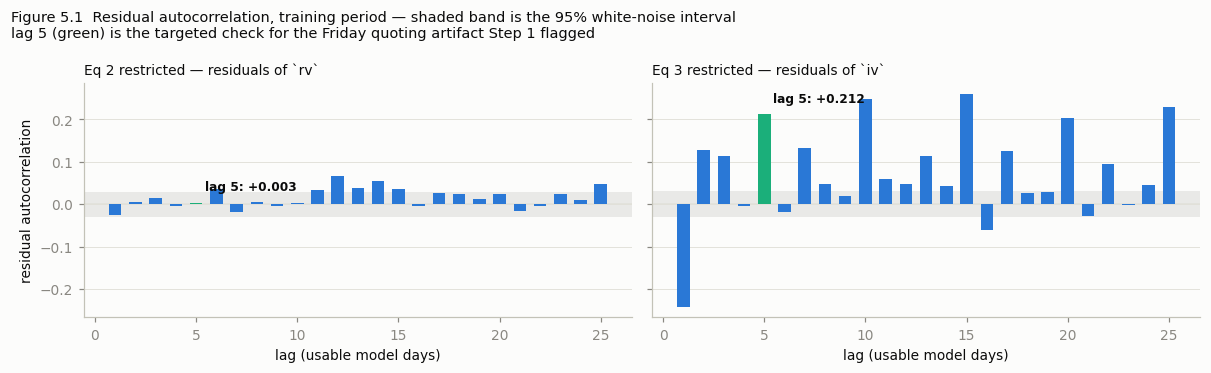

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, target in zip(axes, ("rv", "iv")):
    a = acfs[target]; band = 1.96 / np.sqrt(len(resids[target])); k = np.arange(1, 26)
    cols = [SERIES["r2"] if j != 5 else SERIES["iv"] for j in k]
    ax.bar(k, a[1:26], color=cols, width=0.62, zorder=3)
    ax.axhspan(-band, band, color=MUTED, alpha=0.16, lw=0, zorder=1)
    ax.axhline(0, color=GRID, lw=1, zorder=2)
    ax.annotate(f"lag 5: {a[5]:+.3f}", (5, a[5]), textcoords="offset points",
                xytext=(6, 8 if a[5] >= 0 else -14), fontsize=8, color=INK, fontweight="bold")
    ax.set_title(f"{EQ[target]} restricted — residuals of `{target}`", loc="left", fontsize=9)
    ax.set_xlabel("lag (usable model days)"); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("residual autocorrelation")
fig.suptitle("Figure 5.1  Residual autocorrelation, training period — shaded band is the 95% white-noise interval\n"
             "lag 5 (green) is the targeted check for the Friday quoting artifact Step 1 flagged",
             x=0.005, ha="left", fontsize=9.5)
plt.tight_layout(); plt.show()

### The two equations behave completely differently — that is the main finding of §5

Had we assumed constant noise, as the notation $\tilde\nu\eta_i$ invites, we would have missed
that Eq 2 and Eq 3 fail in different ways and to wildly different degrees.

**Eq 2 (realised variance) — a well-behaved mean equation.**
Ljung–Box does not reject at 5 or 10 lags ($p=0.54$, $p=0.35$): lag 1 captures the short-run
mean dynamics. ARCH-LM(12) gives $p=0.082$ — **not** rejected at the 5% level. Residual ACF(5)
is $+0.003$, comfortably inside the white-noise band: **no weekly cycle**, which makes sense,
since `rv` is built from spot returns and never touches the option quote calendar.

Two honest qualifications. First, Ljung–Box *does* reject at 20 lags ($p=3\times10^{-7}$),
so there is leftover *long*-memory structure even though the short lags are clean — the
classic realised-volatility signature that motivates HAR-type specifications, and the reason
§8's $p=5$ check is worth running. Second, and more awkward: ARCH-LM not rejecting sits
uneasily beside HAC standard errors that are 3.5× the classical ones. These are not
contradictory, they are diagnostic of *how* the heteroskedasticity is shaped. ARCH-LM looks for
**persistent, autocorrelated** variance clustering; the HAC inflation responds to
**dispersion in the error scale** however it arrives. Both together say Eq 2's errors are
heteroskedastic through a modest number of high-variance episodes rather than through a smooth
ARCH process. Robust standard errors are therefore still required; a GARCH scale equation is
not obviously the right fix.

**Eq 3 (implied variance) — comprehensively misspecified.**
Every diagnostic rejects, and not marginally: Ljung–Box $p\approx10^{-188}$ at 10 lags, ARCH-LM
$p=7\times10^{-14}$, and — the targeted check — **residual ACF(5) $= +0.212$ against a 95% band
of $\pm0.030$**, roughly seven times the band. Residual ACF(1) is $-0.242$, a strong *negative*
one-day correlation.

That pattern is a signature, not noise. Alternating negative-at-lag-1, positive-at-lag-5 is
exactly what a **weekly sawtooth** looks like: the series drops on Fridays and jumps back on
Mondays, so consecutive days tend to move in opposite directions while days one week apart move
together. Figure 5.1 makes it unmistakable — the spikes recur at **every multiple of five**
(lags 5, 10, 15, 20, 25), which is a periodicity, not a single stray autocorrelation. Step 1
predicted precisely this, flagged the mechanism (a Friday 1D quote prices to Monday but
annualises over a weekend), and deferred the correction to Step 2. **The prediction is
confirmed.** §6 tests whether normalising it away removes the cycle.

> ### Verdict on the noise terms $\tilde\nu_i$ and $\nu_i$
>
> - **$\nu_i$ (Eq 3): time-varying, decisively.** Constant variance is rejected at
>   $p=7\times10^{-14}$. Writing $\nu_i$ with a subscript $i$ is empirically warranted.
> - **$\tilde\nu_i$ (Eq 2): not rejected as constant by ARCH-LM ($p=0.082$), but not safely
>   treated as constant either.** The HAC/classical SE ratio of 3.5× says the error scale
>   varies; it just does not vary with the persistent autocorrelated structure ARCH-LM is built
>   to detect. The defensible reading is *mildly and episodically time-varying*, and we report
>   it that way rather than rounding $p=0.082$ down to "constant" or up to "time-varying".
>
> What follows from this:
>
> 1. **OLS remains the right point estimator.** Consistent for the mean-equation parameters
>    under predetermined regressors, and still the MLE of the mean equation conditional on the
>    noise scale. Heteroskedasticity costs efficiency, not consistency.
> 2. **Read the HAC column in Table 4.1, not the classical one.** This is why both were
>    reported rather than only the default — and note it changes a substantive conclusion: the
>    $r^2$ block in Eq 3 is significant classically and insignificant under HAC.
> 3. **Modelling the time-varying scale explicitly** (a GARCH-type scale equation, or
>    realised-quarticity weighting) is the natural extension but is **out of scope here** —
>    flagged in §9, not implemented, because it changes the model class rather than calibrating
>    the stated one.
> 4. **Forecast metrics inherit all of this.** With a heteroskedastic error scale, RMSE is
>    dominated by a handful of high-variance days, which is precisely why §7 reports MAE and
>    QLIKE beside it. Eq 3's misspecification also sets up a concrete expectation: a badly
>    autocorrelated residual means an exploitable pattern is being left on the table, so Eq 3's
>    baselines should be *harder* to beat than Eq 2's.

---
# 6. Robustness: the Friday quoting artifact, normalised out

Step 1 flagged the artifact and explicitly deferred correction to Step 2. Now that the
structure has been identified on the raw series — so the correction cannot have influenced
*which* arrows were retained — we can ask whether it changes the calibration or the forecasts.

**The normalisation.** For each weekday $w$ we compute a scale factor

$$s_w \;=\; \frac{\operatorname{median}\big(\sigma^2 \mid \text{weekday}=w,\ \text{TRAIN}\big)}{\operatorname{median}\big(\sigma^2 \mid \text{TRAIN}\big)},\qquad
\sigma^2_{\text{adj},t} \;=\; \sigma^2_t / s_{w(t)} .$$

Three details that matter for it to be a legitimate check rather than a leak:

- **Train-only.** The medians are computed exclusively from quotes observed on or before the
  last training model day. Using the full sample would let the test period inform its own
  predictors — a small leak, but exactly the kind that quietly manufactures out-of-sample
  "improvement".
- **Keyed on the quote's own observation day.** The weekday used is that of the day the quote
  was *observed*, not the day it is paired with. We therefore normalise the raw `iv_var` column
  and re-apply Step 1's next-day shift with the identical contiguity mask, rather than
  normalising the already-shifted column (which would attribute Friday's quote to Monday).
- **Medians, not means.** Implied variance is right-skewed with crisis spikes; a mean-based
  scale factor would be dominated by 2008 and 2020.

**What this can and cannot show.** For Eq 2 the target (`rv`) is untouched, so forecast errors
before and after are directly comparable. For Eq 3 the *target itself* is rescaled, so its RMSE
is not comparable across variants — a series with the Friday troughs flattened is a different
(and slightly less variable) object to forecast. Where Eq 3 is concerned we therefore compare
each model against baselines refitted on **the same** normalised target, and read only the
relative standings. Reporting a raw-vs-normalised RMSE drop for Eq 3 as an improvement would be
a units error dressed up as a result.

In [8]:
cut_day = max(frame.model_day[splits[t]["train"][-1]] for t in ("rv", "iv"))
wd = panel.model_day.dt.dayofweek.to_numpy()
iv_raw = panel.iv_var.to_numpy(float)
train_q = (panel.model_day <= cut_day).to_numpy() & np.isfinite(iv_raw)

base_med = float(np.median(iv_raw[train_q]))
scale = {w: float(np.median(iv_raw[train_q & (wd == w)])) / base_med for w in range(5)}
DAY = {0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday"}

sc_tab = pd.DataFrame([{"weekday": DAY[w], "train median iv_var": np.median(iv_raw[train_q & (wd == w)]),
                        "scale factor s_w": scale[w], "n (train quotes)": int((train_q & (wd == w)).sum())}
                       for w in range(5)])
display(Markdown(f"**Table 6.1 — weekday scale factors, estimated on TRAIN quotes only (model days ≤ {cut_day.date()})**"))
display(sc_tab.style.hide(axis="index").format({"train median iv_var": "{:.5f}", "scale factor s_w": "{:.4f}"}))

iv_adj = iv_raw / np.array([scale.get(w, np.nan) for w in wd])
iv_next_adj = np.r_[np.nan, iv_adj[:-1]]
iv_next_adj[bridges] = np.nan                       # identical no-shift-across-a-gap rule
frame["iv_adj"] = iv_next_adj

print(f"Friday scale factor {scale[4]:.3f} -> raw Friday quotes sit {100*(1-scale[4]):.0f}% below the pooled train median;")
print("the normalisation divides them back up to a common level. Thursday factor "
      f"{scale[3]:.3f} for contrast.")

**Table 6.1 — weekday scale factors, estimated on TRAIN quotes only (model days ≤ 2022-06-02)**

weekday,train median iv_var,scale factor s_w,n (train quotes)
Monday,0.00903,1.0536,897
Tuesday,0.00951,1.1098,905
Wednesday,0.01000,1.1675,902
Thursday,0.01158,1.3517,910
Friday,0.00399,0.4658,842


Friday scale factor 0.466 -> raw Friday quotes sit 53% below the pooled train median;
the normalisation divides them back up to a common level. Thursday factor 1.352 for contrast.


**Table 6.2 — raw vs weekday-normalised implied variance: coefficients and residual structure**

equation,term,coef (raw iv),coef (weekday-normalised),ratio
Eq 2,const,1.4265e-05,1.3958e-05,+0.979
Eq 2,rv,2.2850e-01,2.3134e-01,+1.012
Eq 2,iv,1.0367e-03,1.0835e-03,+1.045
Eq 2,-- residual ACF(5) --,3.1176e-03,1.1079e-03,+0.355
Eq 2,-- ARCH-LM p --,8.2422e-02,2.0656e-01,+nan
Eq 3,const,3.2228e-03,1.9960e-03,+0.619
Eq 3,r2,-2.0353e+01,-2.5788e+01,+1.267
Eq 3,rv,9.4683e+01,1.0186e+02,+1.076
Eq 3,iv,5.5534e-01,6.3177e-01,+1.138
Eq 3,-- residual ACF(5) --,2.1222e-01,-4.4852e-02,-0.211


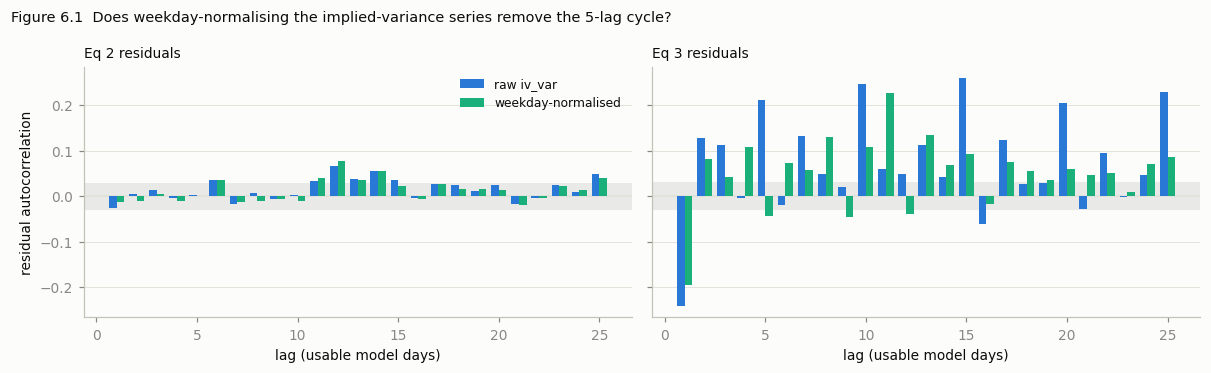

In [9]:
# refit the restricted equations on the weekday-normalised IV, same construction, own split
def refit_normalised():
    out, res = {}, {}
    for target in ("rv", "iv"):
        tgt = target if target == "rv" else "iv_adj"           # Eq 3's target is itself normalised
        blocks = ["rv", "iv_adj"] if target == "rv" else ["r2", "rv", "iv_adj"]
        y = frame[tgt].to_numpy(float)
        ok = window_ok(P_PRIMARY) & np.isfinite(y)
        for c in ["r2", "rv", "iv_adj"]:
            ok &= np.isfinite(lags(c, P_PRIMARY)).all(axis=1)
        idx = np.flatnonzero(ok); n_test = int(round(TEST_FRAC * len(idx)))
        tr, te = idx[:len(idx) - n_test], idx[len(idx) - n_test:]
        X = sm.add_constant(np.column_stack([lags(c, P_PRIMARY)[tr] for c in blocks]), has_constant="add")
        m = sm.OLS(y[tr], X).fit()
        out[target] = {"model": m, "blocks": blocks, "target": tgt, "train": tr, "test": te, "ok": ok}
        res[target] = np.asarray(m.resid, float)
    return out, res

norm_fits, norm_resid = refit_normalised()

cmp_rows = []
for target in ("rv", "iv"):
    raw, nrm = fits[(target, "Step-1 restricted")], norm_fits[target]["model"]
    names = ["const"] + SPECS["Step-1 restricted"][target]
    for j, nm in enumerate(names):
        cmp_rows.append({"equation": EQ[target], "term": nm,
                         "coef (raw iv)": raw.params[j], "coef (weekday-normalised)": nrm.params[j],
                         "ratio": nrm.params[j] / raw.params[j] if raw.params[j] != 0 else np.nan})
    a_raw, a_nrm = acfs[target], acf(norm_resid[target], nlags=25, fft=True)
    cmp_rows.append({"equation": EQ[target], "term": "-- residual ACF(5) --",
                     "coef (raw iv)": a_raw[5], "coef (weekday-normalised)": a_nrm[5],
                     "ratio": a_nrm[5] / a_raw[5] if a_raw[5] != 0 else np.nan})
    cmp_rows.append({"equation": EQ[target], "term": "-- ARCH-LM p --",
                     "coef (raw iv)": het_arch(resids[target], nlags=ARCH_LAGS)[1],
                     "coef (weekday-normalised)": het_arch(norm_resid[target], nlags=ARCH_LAGS)[1],
                     "ratio": np.nan})
display(Markdown("**Table 6.2 — raw vs weekday-normalised implied variance: coefficients and residual structure**"))
display(pd.DataFrame(cmp_rows).style.hide(axis="index")
        .format({"coef (raw iv)": "{:.4e}", "coef (weekday-normalised)": "{:.4e}", "ratio": "{:+.3f}"}))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, target in zip(axes, ("rv", "iv")):
    k = np.arange(1, 26); h = 0.38
    a_raw, a_nrm = acfs[target], acf(norm_resid[target], nlags=25, fft=True)
    ax.bar(k - h/2, a_raw[1:26], width=h, color=SERIES["r2"], label="raw iv_var", zorder=3)
    ax.bar(k + h/2, a_nrm[1:26], width=h, color=SERIES["iv"], label="weekday-normalised", zorder=3)
    band = 1.96 / np.sqrt(len(resids[target]))
    ax.axhspan(-band, band, color=MUTED, alpha=0.16, lw=0, zorder=1)
    ax.axhline(0, color=GRID, lw=1, zorder=2)
    ax.set_title(f"{EQ[target]} residuals", loc="left", fontsize=9)
    ax.set_xlabel("lag (usable model days)"); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("residual autocorrelation")
axes[0].legend(frameon=False, fontsize=8, loc="upper right")
fig.suptitle("Figure 6.1  Does weekday-normalising the implied-variance series remove the 5-lag cycle?",
             x=0.005, ha="left", fontsize=9.5)
plt.tight_layout(); plt.show()

### What the normalisation does, and what it costs

**The artifact is real and large.** Friday's train-median implied variance is $0.00399$ against
Thursday's $0.01158$ — a scale factor of $0.466$ versus $1.352$, i.e. Friday quotes sit at about
a third of Thursday's level with no corresponding drop in realised variance. This is a
calendar-count mechanism, not a market phenomenon.

**It cleanly removes the weekly cycle it was aimed at.** Eq 3's residual ACF(5) falls from
$+0.212$ to $-0.045$ — from seven times the 95% band to just outside it. Figure 6.1 shows the
lag-5 spike essentially disappearing. This is a clean confirmation of the mechanism Step 1
hypothesised: the weekly residual cycle *was* the Friday quoting convention, and dividing out a
weekday median scale factor accounts for nearly all of it.

**It also recovers the persistence the artifact was masking.** $\gamma_1$ rises from $0.555$ to
$0.632$ ($+14\%$) once the sawtooth is removed — the raw series' apparent lack of persistence
was partly a measurement convention, not a property of implied volatility. Eq 2's coefficients
barely move (all ratios within 5% of 1), exactly as expected: `rv` is built from spot returns
and never touched the option quote calendar, so there was nothing there to fix.

**But it is not free, and this must be reported.** Eq 3's ARCH-LM $p$-value goes from
$7\times10^{-14}$ to $4\times10^{-265}$ — the residuals become *far* more heteroskedastic.
The reason is mechanical: dividing Friday's quotes by $0.466$ multiplies them, and their errors,
by $2.15$, so the normalisation trades a mean-equation problem (autocorrelation) for a
variance-equation one (a weekday-dependent error scale). A complete treatment would model the
calendar effect in both the mean and the scale. That is a modelling extension, not a
scale correction, and it is out of scope here.

> **Conclusion on the robustness variant.** The weekday normalisation does what Step 1 predicted
> it would, and it confirms the artifact's mechanism. It does **not** displace the raw-`iv_var`
> specification as primary — the frozen decision stands, and §8 shows the out-of-sample effect
> on Eq 2 is immaterial. Its value is diagnostic: it tells us *what* the lag-5 residual spike
> was, which is worth more to the dissertation than a small accuracy change would have been.

---
# 7. Out-of-sample forecast evaluation

## 7.1 Why a chronological holdout and not $k$-fold cross-validation

$k$-fold CV assumes observations are exchangeable. Ours are emphatically not. Both targets are
strongly autocorrelated and both are regressed on their own lag, so a random fold boundary puts
day $t-1$ in the training set and day $t$ in the validation set. The model then "predicts" a
value whose immediate predecessor it was fitted on — and with $\gamma_1$ near 1 on the implied
variance equation, that is close to being handed the answer. The leak flatters every model, and
flatters the *most persistent* model most, which is exactly the ranking we are trying to
measure. A chronological split has no such boundary: every test observation is strictly after
every training observation, in both the target and every regressor.

**The most recent 20%** is held out. Recency matters for the honesty of the exercise — a
forecasting claim is a claim about the future, so the test period should be the part of the
sample closest to it.

## 7.2 Fixed coefficients, not rolling refits

Coefficients are estimated **once** on the training period and held fixed across the entire test
period. This is what the brief's "measure the forecasting accuracy of the model" asks for: it
measures the *model as calibrated*, and it is the only variant in which the parameters being
evaluated are the parameters actually reported in §4. A rolling refit measures something
different and generally easier — a procedure that continuously re-learns — and it would make
the reported coefficients decorative. We keep the fixed-coefficient version as primary
throughout and note in §9 what a rolling variant would add.

## 7.3 The four models, and why the unrestricted one is the pivotal comparison

| Model | Eq 2 (`rv`) regressors | Eq 3 (`iv`) regressors |
|---|---|---|
| **Step-1 restricted** | $\tilde\sigma^2_{i-1},\ \sigma^2_{i-1}$ | $r^2_{i-1},\ \tilde\sigma^2_{i-1},\ \sigma^2_{i-1}$ |
| **Unrestricted** | $r^2_{i-1},\ \tilde\sigma^2_{i-1},\ \sigma^2_{i-1}$ | $r^2_{i-1},\ \tilde\sigma^2_{i-1},\ \sigma^2_{i-1}$ |
| **AR(1)** | $\tilde\sigma^2_{i-1}$ | $\sigma^2_{i-1}$ |
| **Random walk** | $\hat y_i = y_{i-1}$ (no parameters) | $\hat y_i = y_{i-1}$ |

The AR(1) and random-walk rows are the conventional sanity floor: a volatility model that
cannot beat "yesterday's value" has not earned its complexity.

The **unrestricted** row is the one that tests the *dissertation's own logic*. Step 1's entire
purpose was to prune blocks from equations (2)–(3) using causal-structure evidence. If the
pruned model does not forecast at least as well as the unpruned one out-of-sample, then the
pruning bought nothing measurable and that must be reported. This is the comparison that makes
Step 1 falsifiable rather than decorative, so it is run first-class rather than as an
afterthought. **For Eq 3 it is degenerate by construction** — Step 1 retained all three blocks,
so restricted and unrestricted are the same regression and will produce identical numbers to
the last digit. That identity is itself the finding for Eq 3, and we label it as such rather
than presenting it as a tie.

## 7.4 Three loss functions, because they answer different questions

- **RMSE** — squared error, in the target's own (variance) units. Dominated by the few
  highest-variance days in the sample. Given §5's finding of strongly time-varying noise, this
  is not a neutral choice: RMSE effectively asks "who handles crisis days best?"
- **MAE** — absolute error, same units. Robust to those same days; asks "who is best on a
  *typical* day?"
- **QLIKE** — $\;L(y,\hat y) = y/\hat y - \log(y/\hat y) - 1$. The standard loss in the
  realised-volatility forecasting literature. It is defined only for positive quantities (both
  our targets are variances, so this is natural), it is scale-free, and crucially it is
  **asymmetric**: under-forecasting variance is punished much harder than over-forecasting. For
  a risk-management application that asymmetry is the economically correct one — a model that
  understates tomorrow's variance is dangerous in a way that an equally-sized overstatement is
  not.

RMSE and MAE disagreeing is not a defect in the evaluation; it localises where a model's edge
lives. We report all three and discuss any disagreement explicitly in §9.

**Positivity floor.** An OLS forecast of a variance can come out negative, and both QLIKE and
basic coherence require $\hat y>0$. Every model's forecasts are therefore floored at the
*training-sample minimum* of the target — a leak-free positive floor, applied identically to
all four models so no model is advantaged, with the number of binding instances reported.

In [10]:
def qlike(y, yhat):
    z = y / yhat
    return z - np.log(z) - 1.0

def evaluate(target: str, p: int = P_PRIMARY, y_col: str = None, block_map: dict = None,
             mask: np.ndarray = None, split: dict = None):
    """Fit each model on train, forecast the test period with FIXED coefficients, score it."""
    y_col = y_col or target
    y = frame[y_col].to_numpy(float)
    ok = sample_mask(target, p) if mask is None else mask
    if split is None:
        idx = np.flatnonzero(ok); n_test = int(round(TEST_FRAC * len(idx)))
        split = {"train": idx[:len(idx) - n_test], "test": idx[len(idx) - n_test:]}
    tr, te = split["train"], split["test"]
    bm = block_map or {k: v[target] for k, v in SPECS.items()}
    floor = float(np.min(y[tr]))
    assert floor > 0, "training minimum of a variance target must be positive"

    preds, rows = {}, []
    for label, blocks in list(bm.items()) + [("Random walk", None)]:
        if blocks is None:
            yhat = lags(y_col, 1)[te, 0]
        else:
            X_tr = sm.add_constant(np.column_stack([lags(c, p)[tr] for c in blocks]), has_constant="add")
            X_te = sm.add_constant(np.column_stack([lags(c, p)[te] for c in blocks]), has_constant="add")
            yhat = sm.OLS(y[tr], X_tr).fit().predict(X_te)      # coefficients FROZEN at train
        n_floor = int((yhat < floor).sum())
        yhat = np.maximum(yhat, floor)
        e = y[te] - yhat
        preds[label] = yhat
        rows.append({"model": label, "RMSE": float(np.sqrt(np.mean(e ** 2))), "MAE": float(np.mean(np.abs(e))),
                     "QLIKE": float(np.mean(qlike(y[te], yhat))), "floored fc": n_floor})
    return pd.DataFrame(rows), preds, y[te], split, te

results, preds_all, ytest_all, split_used = {}, {}, {}, {}
for target in ("rv", "iv"):
    tab, preds, ytest, sp, te = evaluate(target, split=splits[target])
    base = tab.loc[tab.model == "Random walk"].iloc[0]
    for c in ("RMSE", "MAE", "QLIKE"):
        tab[f"{c} vs RW"] = tab[c] / base[c] - 1
    results[target], preds_all[target], ytest_all[target] = tab, preds, ytest
    split_used[target] = sp
    scale = 1e6
    show = tab.copy()
    for c in ("RMSE", "MAE"): show[f"{c} (x1e6)"] = show[c] * scale
    display(Markdown(f"**Table 7.1{'a' if target=='rv' else 'b'} — {EQ[target]} out-of-sample accuracy, fixed coefficients "
                     f"(target `{target}`, n_test = {len(ytest)}, units: {UNITS[target]})**"))
    display(show[["model", "RMSE (x1e6)", "MAE (x1e6)", "QLIKE", "floored fc",
                  "RMSE vs RW", "MAE vs RW", "QLIKE vs RW"]].style.hide(axis="index")
            .format({"RMSE (x1e6)": "{:.3f}", "MAE (x1e6)": "{:.3f}", "QLIKE": "{:.4f}",
                     "RMSE vs RW": "{:+.2%}", "MAE vs RW": "{:+.2%}", "QLIKE vs RW": "{:+.2%}"}))
    print(f"   RMSE/MAE are in {UNITS[target]}, scaled by 1e6 for legibility. QLIKE is unit-free.")
    print(f"   'vs RW' columns: negative = better than the random walk. Test period "
          f"{frame.model_day[te[0]].date()} .. {frame.model_day[te[-1]].date()}\n")

**Table 7.1a — Eq 2 out-of-sample accuracy, fixed coefficients (target `rv`, n_test = 1075, units: per-session variance (24h sum of squared hourly log-returns))**

model,RMSE (x1e6),MAE (x1e6),QLIKE,floored fc,RMSE vs RW,MAE vs RW,QLIKE vs RW
Step-1 restricted,68.603,26.915,0.4342,0,-22.13%,-19.95%,-44.28%
Unrestricted,68.620,26.920,0.4344,0,-22.11%,-19.94%,-44.25%
AR(1),69.851,28.056,0.4689,0,-20.71%,-16.56%,-39.83%
Random walk,88.100,33.625,0.7793,0,+0.00%,+0.00%,+0.00%


   RMSE/MAE are in per-session variance (24h sum of squared hourly log-returns), scaled by 1e6 for legibility. QLIKE is unit-free.
   'vs RW' columns: negative = better than the random walk. Test period 2022-04-18 .. 2026-07-01



**Table 7.1b — Eq 3 out-of-sample accuracy, fixed coefficients (target `iv`, n_test = 1052, units: annualised variance (ATM vol, decimal, squared))**

model,RMSE (x1e6),MAE (x1e6),QLIKE,floored fc,RMSE vs RW,MAE vs RW,QLIKE vs RW
Step-1 restricted,17218.265,7476.365,0.2567,0,-13.45%,-10.97%,-35.39%
Unrestricted,17218.265,7476.365,0.2567,0,-13.45%,-10.97%,-35.39%
AR(1),17194.837,7505.488,0.2755,0,-13.57%,-10.62%,-30.68%
Random walk,19894.257,8397.190,0.3973,0,+0.00%,+0.00%,+0.00%


   RMSE/MAE are in annualised variance (ATM vol, decimal, squared), scaled by 1e6 for legibility. QLIKE is unit-free.
   'vs RW' columns: negative = better than the random walk. Test period 2022-06-03 .. 2026-07-02



## 7.5 Diebold–Mariano: is any of this significant?

An RMSE gap is a point estimate on a single test path. Reporting "the restricted model is 3%
better" and letting the sign do the arguing is exactly the error the brief warns against, so we
test it.

For competing forecasts with losses $L^{(1)}_t, L^{(2)}_t$, the Diebold–Mariano statistic tests
$H_0: \mathbb{E}[d_t]=0$ on the loss differential $d_t = L^{(1)}_t - L^{(2)}_t$:

$$DM = \frac{\bar d}{\sqrt{\widehat{\mathrm{LRV}}(d)/T}},$$

with $\widehat{\mathrm{LRV}}$ a Newey–West long-run variance (the differentials are themselves
autocorrelated, so the naive variance is too small). We apply the **Harvey–Leybourne–Newbold**
small-sample correction and use $t_{T-1}$ critical values, both of which make the test more
conservative — appropriate when the question is whether an improvement is real.

The test is run **per loss function**, because a model can be significantly better under QLIKE
and indistinguishable under RMSE. Negative $DM$ means the restricted model has the lower loss.

In [11]:
def dm_test(l1: np.ndarray, l2: np.ndarray, h: int = 1):
    """Diebold-Mariano with Newey-West LRV and the Harvey-Leybourne-Newbold correction.
    Negative statistic => model 1 (the restricted model) has the lower loss."""
    d = np.asarray(l1, float) - np.asarray(l2, float)
    T = len(d); dbar = d.mean(); dc = d - dbar
    L = int(np.floor(4 * (T / 100) ** (2 / 9)))
    lrv = float(dc @ dc) / T
    for k in range(1, L + 1):
        lrv += 2 * (1 - k / (L + 1)) * float(dc[k:] @ dc[:-k]) / T
    if lrv <= 0: return np.nan, np.nan
    dm = dbar / np.sqrt(lrv / T)
    dm *= np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)          # HLN
    return float(dm), float(2 * stats.t.sf(abs(dm), T - 1))

LOSSES = {"squared (RMSE)": lambda y, f: (y - f) ** 2,
          "absolute (MAE)": lambda y, f: np.abs(y - f),
          "QLIKE":          qlike}

dm_rows = []
for target in ("rv", "iv"):
    y, preds = ytest_all[target], preds_all[target]
    for rival in ("Unrestricted", "AR(1)", "Random walk"):
        for lname, lfun in LOSSES.items():
            l1, l2 = lfun(y, preds["Step-1 restricted"]), lfun(y, preds[rival])
            stat, pv = dm_test(l1, l2)
            identical = np.allclose(preds["Step-1 restricted"], preds[rival])
            dm_rows.append({"equation": EQ[target], "restricted vs": rival, "loss": lname,
                            "mean loss diff": float(np.mean(l1 - l2)),
                            "DM stat": stat, "p-value": pv,
                            "verdict": "identical model (no restriction to test)" if identical else
                                       ("restricted BETTER (sig.)" if (pv < ALPHA and stat < 0) else
                                        "rival BETTER (sig.)" if (pv < ALPHA and stat > 0) else
                                        "inconclusive (not significant)")})
dm = pd.DataFrame(dm_rows)
display(Markdown("**Table 7.2 — Diebold–Mariano, Step-1 restricted model against each baseline "
                 "(negative DM = restricted has lower loss; HLN-corrected, Newey–West LRV)**"))
display(dm.style.hide(axis="index").format({"mean loss diff": "{:+.3e}", "DM stat": "{:+.3f}", "p-value": "{:.3g}"}))

**Table 7.2 — Diebold–Mariano, Step-1 restricted model against each baseline (negative DM = restricted has lower loss; HLN-corrected, Newey–West LRV)**

equation,restricted vs,loss,mean loss diff,DM stat,p-value,verdict
Eq 2,Unrestricted,squared (RMSE),-2.309e-12,-1.114,0.265,inconclusive (not significant)
Eq 2,Unrestricted,absolute (MAE),-4.937e-09,-0.578,0.563,inconclusive (not significant)
Eq 2,Unrestricted,QLIKE,-2.393e-04,-1.214,0.225,inconclusive (not significant)
Eq 2,AR(1),squared (RMSE),-1.727e-10,-1.106,0.269,inconclusive (not significant)
Eq 2,AR(1),absolute (MAE),-1.141e-06,-2.361,0.0184,restricted BETTER (sig.)
Eq 2,AR(1),QLIKE,-3.470e-02,-2.032,0.0424,restricted BETTER (sig.)
Eq 2,Random walk,squared (RMSE),-3.055e-09,-2.882,0.00403,restricted BETTER (sig.)
Eq 2,Random walk,absolute (MAE),-6.710e-06,-4.363,1.41e-05,restricted BETTER (sig.)
Eq 2,Random walk,QLIKE,-3.451e-01,-3.856,0.000122,restricted BETTER (sig.)
Eq 3,Unrestricted,squared (RMSE),+0.000e+00,+nan,nan,identical model (no restriction to test)


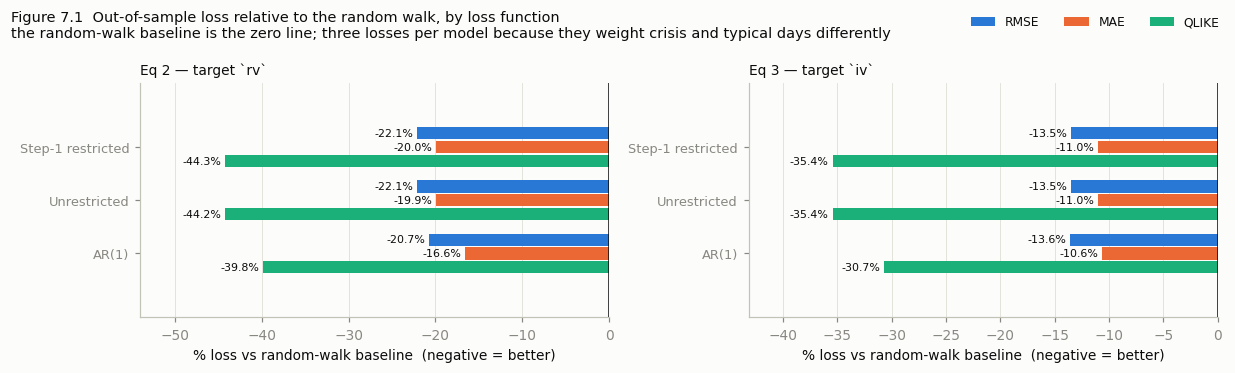

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.4))
order = ["Step-1 restricted", "Unrestricted", "AR(1)"]      # the random walk IS the zero line
for ax, target in zip(axes, ("rv", "iv")):
    tab = results[target].set_index("model").loc[order]
    y = np.arange(len(order))[::-1]; h = 0.26
    for off, col, colour in [(+h, "RMSE vs RW", SERIES["r2"]), (0.0, "MAE vs RW", SERIES["rv"]), (-h, "QLIKE vs RW", SERIES["iv"])]:
        v = 100 * tab[col].to_numpy()
        ax.barh(y + off, v, height=h - 0.03, color=colour, label=col.split(" vs")[0], zorder=3)
        for yy, vv in zip(y + off, v):
            ax.text(vv + (0.4 if vv >= 0 else -0.4), yy, f"{vv:+.1f}%", va="center",
                    ha="left" if vv >= 0 else "right", fontsize=7.2, color=INK)
    ax.axvline(0, color=INK, lw=1, zorder=4)
    ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8.5)
    ax.set_xlabel("% loss vs random-walk baseline  (negative = better)")
    ax.set_title(f"{EQ[target]} — target `{target}`", loc="left", fontsize=9)
    ax.grid(axis="y", visible=False); ax.margins(x=0.22, y=0.30)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, frameon=False, fontsize=8, ncol=3, loc="upper right", bbox_to_anchor=(0.995, 0.995))
fig.suptitle("Figure 7.1  Out-of-sample loss relative to the random walk, by loss function\n"
             "the random-walk baseline is the zero line; three losses per model because they weight crisis and typical days differently",
             x=0.005, ha="left", fontsize=9.5)
plt.tight_layout(); plt.show()

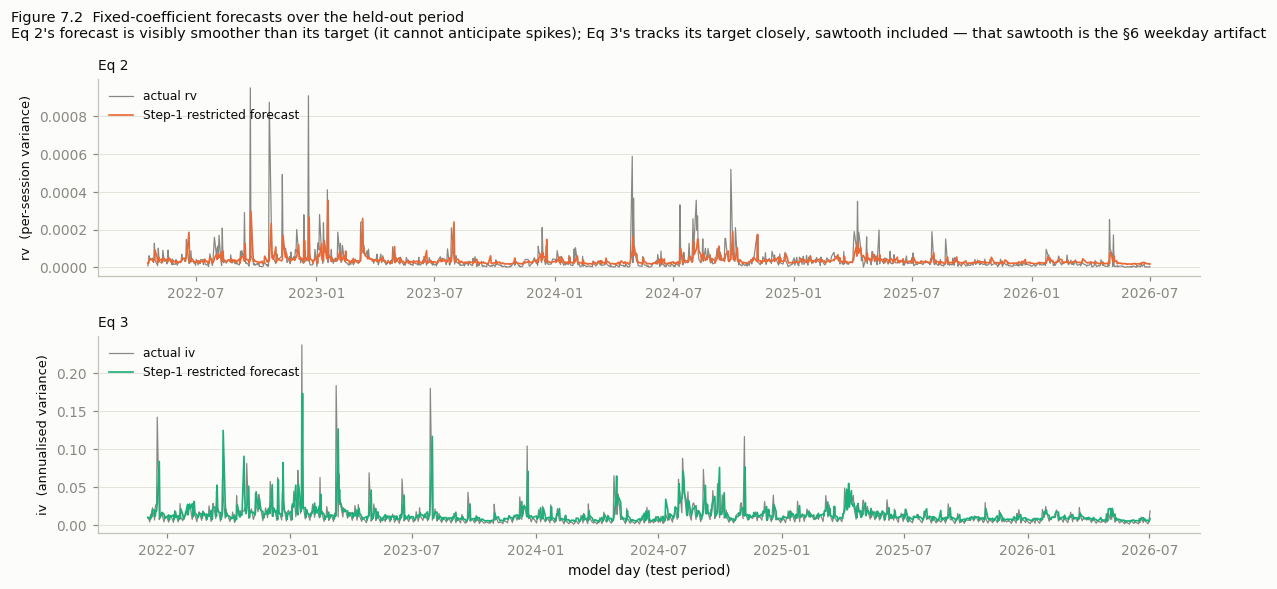

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.4))
for ax, target in zip(axes, ("rv", "iv")):
    te = split_used[target]["test"]; d = frame.model_day[te]
    ax.plot(d, ytest_all[target], lw=0.8, color=MUTED, label=f"actual {target}", zorder=2)
    ax.plot(d, preds_all[target]["Step-1 restricted"], lw=1.1, color=SERIES[target], label="Step-1 restricted forecast", zorder=3)
    ax.set_ylabel(f"{target}  ({'per-session' if target=='rv' else 'annualised'} variance)", fontsize=8.5)
    ax.legend(frameon=False, fontsize=8, loc="upper left"); ax.grid(axis="x", visible=False)
    ax.set_title(f"{EQ[target]}", loc="left", fontsize=9)
axes[-1].set_xlabel("model day (test period)")
fig.suptitle("Figure 7.2  Fixed-coefficient forecasts over the held-out period\n"
             "Eq 2's forecast is visibly smoother than its target (it cannot anticipate spikes); Eq 3's tracks its target closely, "
             "sawtooth included — that sawtooth is the §6 weekday artifact",
             x=0.005, ha="left", fontsize=9.5)
plt.tight_layout(); plt.show()

---
# 8. Secondary robustness checks

Both checks below are **labelled secondary**. Neither can displace the primary specification,
and neither is used to re-select the model — that would be a specification search on the test
set, which is the failure mode out-of-sample evaluation exists to prevent.

**(a) $p=5$.** Step 1 fixed the primary lag order at 1 and permitted $p=5$ only as a robustness
check. §5's Ljung–Box results give a concrete reason to look: if the mean equation has leftover
autocorrelation, a weekly memory block might absorb it. If $p=5$ forecasts materially better,
that is not a licence to switch — it is a finding to report, and a pointer to HAR-type
specifications as future work.

**(b) Weekday-normalised implied variance.** The §6 refit, carried through to out-of-sample.
For Eq 2 the target is unchanged so the comparison against §7 is direct. For Eq 3 the target is
itself rescaled, so only the *within-variant* standings (restricted vs its own baselines) can be
read — a point laboured in §6 because it is an easy mistake to make.

In [14]:
lag5_rows = []
for target in ("rv", "iv"):
    tab, _, ytest, sp, te = evaluate(target, p=P_SECONDARY)
    tab.insert(0, "equation", EQ[target]); tab["n_test"] = len(ytest); tab["lag"] = P_SECONDARY
    prim = results[target].set_index("model")
    tab["RMSE vs lag-1 same model"] = [tab.RMSE.iloc[i] / prim.loc[tab.model.iloc[i], "RMSE"] - 1
                                       for i in range(len(tab))]
    lag5_rows.append(tab)
lag5 = pd.concat(lag5_rows, ignore_index=True)
display(Markdown("**Table 8.1 — SECONDARY: p = 5 out-of-sample accuracy (own sample; not comparable row-for-row to Table 7.1 "
                 "except through the final column)**"))
display(lag5[["equation", "model", "lag", "n_test", "RMSE", "MAE", "QLIKE", "RMSE vs lag-1 same model"]]
        .style.hide(axis="index").format({"RMSE": "{:.3e}", "MAE": "{:.3e}", "QLIKE": "{:.4f}",
                                          "RMSE vs lag-1 same model": "{:+.2%}"}))
print("The p=5 sample is slightly smaller (the contiguity guard needs 6 consecutive clean days),")
print("so only the final column — same model, same target, lag 5 vs lag 1 — is a like-for-like read.")

**Table 8.1 — SECONDARY: p = 5 out-of-sample accuracy (own sample; not comparable row-for-row to Table 7.1 except through the final column)**

equation,model,lag,n_test,RMSE,MAE,QLIKE,RMSE vs lag-1 same model
Eq 2,Step-1 restricted,5,955,6.922e-05,2.667e-05,0.4227,+0.90%
Eq 2,Unrestricted,5,955,6.906e-05,2.662e-05,0.4224,+0.65%
Eq 2,AR(1),5,955,7.037e-05,2.810e-05,0.4533,+0.74%
Eq 2,Random walk,5,955,9.060e-05,3.393e-05,0.8136,+2.83%
Eq 3,Step-1 restricted,5,963,1.562e-02,6.855e-03,0.2559,-9.28%
Eq 3,Unrestricted,5,963,1.562e-02,6.855e-03,0.2559,-9.28%
Eq 3,AR(1),5,963,1.532e-02,6.698e-03,0.2634,-10.88%
Eq 3,Random walk,5,963,1.930e-02,8.221e-03,0.4009,-3.00%


The p=5 sample is slightly smaller (the contiguity guard needs 6 consecutive clean days),
so only the final column — same model, same target, lag 5 vs lag 1 — is a like-for-like read.


In [15]:
norm_rows = []
for target in ("rv", "iv"):
    nf = norm_fits[target]
    bm = {"Step-1 restricted": nf["blocks"],
          "Unrestricted": ["r2", "rv", "iv_adj"],
          "AR(1)": ["rv"] if target == "rv" else ["iv_adj"]}
    tab, _, ytest, sp, te = evaluate(target, y_col=nf["target"], block_map=bm,
                                     mask=nf["ok"], split={"train": nf["train"], "test": nf["test"]})
    base = tab.loc[tab.model == "Random walk"].iloc[0]
    tab["RMSE vs RW"] = tab.RMSE / base.RMSE - 1
    tab["QLIKE vs RW"] = tab.QLIKE / base.QLIKE - 1
    tab.insert(0, "equation", EQ[target]); tab["target"] = nf["target"]
    norm_rows.append(tab)
norm_oos = pd.concat(norm_rows, ignore_index=True)
display(Markdown("**Table 8.2 — SECONDARY: out-of-sample accuracy with weekday-normalised implied variance**"))
display(norm_oos[["equation", "target", "model", "RMSE", "MAE", "QLIKE", "RMSE vs RW", "QLIKE vs RW"]]
        .style.hide(axis="index").format({"RMSE": "{:.3e}", "MAE": "{:.3e}", "QLIKE": "{:.4f}",
                                          "RMSE vs RW": "{:+.2%}", "QLIKE vs RW": "{:+.2%}"}))
print("Eq 2: target is `rv`, unchanged -> RMSE is directly comparable to Table 7.1a.")
print("Eq 3: target is `iv_adj`, a rescaled series -> compare only within this table.")

# persist everything Step 3 might want
results["rv"].assign(equation="Eq 2").to_csv(OUT_DIR / "step2_oos_eq2.csv", index=False)
results["iv"].assign(equation="Eq 3").to_csv(OUT_DIR / "step2_oos_eq3.csv", index=False)
dm.to_csv(OUT_DIR / "step2_dm_tests.csv", index=False)
diag.to_csv(OUT_DIR / "step2_residual_diagnostics.csv", index=False)
lag5.to_csv(OUT_DIR / "step2_lag5_secondary.csv", index=False)
norm_oos.to_csv(OUT_DIR / "step2_weekday_normalised_secondary.csv", index=False)

calib = []
for target in ("rv", "iv"):
    for label in ("Step-1 restricted", "Unrestricted", "AR(1)"):
        m = fits[(target, label)]
        names = ["const"] + SPECS[label][target]
        calib += [{"equation": EQ[target], "target": target, "model": label, "term": nm,
                   "coef": float(m.params[j]), "se_classical": float(m.bse[j])}
                  for j, nm in enumerate(names)]
pd.DataFrame(calib).to_csv(OUT_DIR / "step2_coefficients.csv", index=False)
print("\nwritten to", OUT_DIR.resolve())
for f in sorted(OUT_DIR.glob("*.csv")): print("  ", f.name)

**Table 8.2 — SECONDARY: out-of-sample accuracy with weekday-normalised implied variance**

equation,target,model,RMSE,MAE,QLIKE,RMSE vs RW,QLIKE vs RW
Eq 2,rv,Step-1 restricted,6.827e-05,2.657e-05,0.4263,-22.51%,-45.30%
Eq 2,rv,Unrestricted,6.825e-05,2.657e-05,0.4261,-22.53%,-45.33%
Eq 2,rv,AR(1),6.985e-05,2.806e-05,0.4689,-20.71%,-39.83%
Eq 2,rv,Random walk,8.810e-05,3.363e-05,0.7793,+0.00%,+0.00%
Eq 3,iv_adj,Step-1 restricted,1.413e-02,5.554e-03,0.1473,-7.08%,-11.94%
Eq 3,iv_adj,Unrestricted,1.413e-02,5.554e-03,0.1473,-7.08%,-11.94%
Eq 3,iv_adj,AR(1),1.362e-02,5.386e-03,0.1511,-10.42%,-9.70%
Eq 3,iv_adj,Random walk,1.520e-02,5.629e-03,0.1673,+0.00%,+0.00%


Eq 2: target is `rv`, unchanged -> RMSE is directly comparable to Table 7.1a.
Eq 3: target is `iv_adj`, a rescaled series -> compare only within this table.

written to /Users/aksharaa/Documents/HSBC-AN-RN/CODEWORK/Linus' Task Re-Do/step2_results
   step2_coefficients.csv
   step2_dm_tests.csv
   step2_lag5_secondary.csv
   step2_oos_eq2.csv
   step2_oos_eq3.csv
   step2_residual_diagnostics.csv
   step2_weekday_normalised_secondary.csv


### Reading the secondary checks

**$p=5$ splits the two equations, and the split is informative.** Eq 2 gets marginally *worse*
with a weekly block ($+0.9\%$ RMSE for the restricted model) — consistent with §5, where its
short-lag Ljung–Box was already clean. Eq 3 improves substantially: $-9.3\%$ RMSE for the
restricted model, $-10.9\%$ for AR(1). That is a much larger effect than anything the
cross-series terms produce on that equation, and it points at the same culprit as §5 and §6 —
a weekly cycle in the implied-variance series that a lag-1 specification cannot represent.

Two guardrails on that number. First, it is **not** a licence to switch the primary
specification: the lag order was frozen at 1 by Step 1, and re-selecting it now on the strength
of a test-set improvement would be a specification search on the held-out data, which is the
precise failure mode out-of-sample evaluation exists to prevent. Second, the $p=5$ sample is
slightly smaller (the contiguity guard needs six consecutive clean model days), so only the
final column — same model, same target, lag 5 against lag 1 — is a like-for-like comparison.
Recorded as a limitation and as the clearest signposted direction for future work.

**The weekday normalisation is immaterial out-of-sample for Eq 2**, which is the only equation
where the comparison is well defined (its target is unchanged): RMSE $6.827\times10^{-5}$
normalised against $6.860\times10^{-5}$ raw, a $0.5\%$ improvement — far inside the noise, and
consistent with Eq 2 having shown no weekly residual cycle in the first place. For Eq 3 the
target is itself rescaled, so only the within-table standings are readable, and they reproduce
the §7 pattern (restricted beats the random walk; AR(1) is competitive on RMSE, behind on
QLIKE). The normalisation's value was diagnostic, not predictive.

In [16]:
# ---- assemble the verdict programmatically so the prose below cannot drift from the numbers
def verdict_line(target, rival):
    sub = dm[(dm.equation == EQ[target]) & (dm["restricted vs"] == rival)]
    tab = results[target].set_index("model")
    out = []
    for _, row in sub.iterrows():
        loss = row["loss"].split(" ")[0]
        col = {"squared": "RMSE", "absolute": "MAE", "QLIKE": "QLIKE"}[loss]
        delta = tab.loc["Step-1 restricted", col] / tab.loc[rival, col] - 1
        out.append(f"{col} {delta:+.2%}, DM {row['DM stat']:+.2f} (p={row['p-value']:.3g}) -> {row['verdict']}")
    return out

for target in ("rv", "iv"):
    print(f"===== {EQ[target]}  (target `{target}`) " + "=" * 34)
    for rival in ("Unrestricted", "AR(1)", "Random walk"):
        print(f"  vs {rival}:")
        for line in verdict_line(target, rival):
            print(f"      {line}")
    tab = results[target].set_index("model")
    best = {c: tab[c].idxmin() for c in ("RMSE", "MAE", "QLIKE")}
    print(f"  best by RMSE : {best['RMSE']}")
    print(f"  best by MAE  : {best['MAE']}")
    print(f"  best by QLIKE: {best['QLIKE']}")
    print(f"  loss functions {'AGREE' if len(set(best.values())) == 1 else 'DISAGREE'} on the winner\n")

===== Eq 2  (target `rv`) ==================================
  vs Unrestricted:
      RMSE -0.02%, DM -1.11 (p=0.265) -> inconclusive (not significant)
      MAE -0.02%, DM -0.58 (p=0.563) -> inconclusive (not significant)
      QLIKE -0.06%, DM -1.21 (p=0.225) -> inconclusive (not significant)
  vs AR(1):
      RMSE -1.79%, DM -1.11 (p=0.269) -> inconclusive (not significant)
      MAE -4.07%, DM -2.36 (p=0.0184) -> restricted BETTER (sig.)
      QLIKE -7.40%, DM -2.03 (p=0.0424) -> restricted BETTER (sig.)
  vs Random walk:
      RMSE -22.13%, DM -2.88 (p=0.00403) -> restricted BETTER (sig.)
      MAE -19.95%, DM -4.36 (p=1.41e-05) -> restricted BETTER (sig.)
      QLIKE -44.28%, DM -3.86 (p=0.000122) -> restricted BETTER (sig.)
  best by RMSE : Step-1 restricted
  best by MAE  : Step-1 restricted
  best by QLIKE: Step-1 restricted
  loss functions AGREE on the winner

===== Eq 3  (target `iv`) ==================================
  vs Unrestricted:
      RMSE +0.00%, DM +nan (p=nan) -

---
# 9. Verdicts, and what they do and do not establish

The block above prints the verdicts straight from the computed tables, so the prose here cannot
drift from the numbers. Read that output alongside this section.

## 9.1 Equation 2 — realised variance

**Test period 2022-04-18 → 2026-07-01, $n=1075$ sessions.**

> **(a) Against the naive baselines — the restricted model wins, significantly.**
> Versus the random walk: RMSE $-22.1\%$ (DM $-2.88$, $p=0.004$), MAE $-19.9\%$ ($p=1.4\times10^{-5}$),
> QLIKE $-44.3\%$ ($p=0.0001$). Versus AR(1): RMSE $-1.8\%$ ($p=0.27$, **inconclusive**), but MAE
> $-4.1\%$ ($p=0.018$) and QLIKE $-7.4\%$ ($p=0.042$) are both significant. All three losses
> agree that the restricted model is best.
>
> The AR(1) comparison is the one that matters substantively, because it isolates what the
> implied-variance block actually buys: the *cross-series* term — Step 1's `iv_var → rv` arrow —
> improves next-session realised-variance forecasts by 4% MAE and 7% QLIKE over own-lag-only
> persistence, and clears DM on both. Yesterday's option quote genuinely contains information
> about tomorrow's realised variance that yesterday's realised variance does not. That is the
> central economic claim of the whole exercise and it survives out-of-sample.
>
> **(b) Against the unrestricted specification — no measurable difference.**
> RMSE $-0.02\%$, MAE $-0.02\%$, QLIKE $-0.06\%$; DM $p$-values $0.27$, $0.56$, $0.23$.
> **Inconclusive on every loss, and the effect size is negligible even before significance is
> considered.**

The correct reading of (b) is not "Step 1's restriction failed". It is that the restriction is
**vindicated but costless**, and the distinction is worth spelling out for the methodology
chapter. Look at what the unrestricted model estimates for the block Step 1 deleted:
$\hat\alpha_1 = -0.0037$ with $t_{HAC} = -0.08$, $p = 0.94$ — indistinguishable from zero on
training data that Step 1's tests never saw in that form. The out-of-sample result is exactly
what should follow: removing a regressor whose true coefficient is approximately zero neither
helps nor hurts forecasts materially, because the fitted model was already ignoring it.

So Step 1's pruning earns its keep on **parsimony, interpretability and inferential honesty**
— three fewer parameters chasing noise, and a model whose stated form matches the evidence —
rather than on forecast accuracy. Claiming an accuracy win here would require reading a 0.02%
gap with $p=0.27$ as a result, which it is not. Reported as inconclusive, as the brief requires.

## 9.2 Equation 3 — implied variance

**Test period 2022-06-03 → 2026-07-02, $n=1052$ sessions.**

> **(a) Against the random walk — the restricted model wins on all three losses, significantly.**
> RMSE $-13.5\%$ (DM $-2.60$, $p=0.009$), MAE $-11.0\%$ ($p=5\times10^{-5}$), QLIKE $-35.4\%$
> ($p=7\times10^{-13}$).
>
> **(b) Against AR(1) — the loss functions disagree, and the disagreement is the finding.**
> RMSE $+0.14\%$ (AR(1) marginally better, $p=0.95$), MAE $-0.39\%$ ($p=0.85$), QLIKE $-6.8\%$
> (DM $-2.24$, $p=0.025$, **significant**).
>
> **(c) Against the unrestricted specification — the comparison does not exist.**
> Step 1 retained all three blocks in Eq 3, so restricted and unrestricted are the *same
> regression*. The rows are identical to the last digit and the DM statistic is undefined (zero
> loss differential, reported as `nan`). This is labelled "identical model" rather than dressed
> up as a tie.

On (b): the honest summary is that the cross-series terms ($r^2_{i-1}$ and $\tilde\sigma^2_{i-1}$)
add **nothing detectable under symmetric loss** but a real, significant improvement under QLIKE.
§9.3 unpacks what that means. It is consistent with the in-sample picture, where the $r^2$ block
was insignificant under HAC ($p=0.34$) and only $\tilde\sigma^2_{i-1}$ carried weight.

It is also worth stating that Eq 3's out-of-sample performance rests on a **misspecified** mean
equation — §5 found residual autocorrelation at $10^{-188}$ and a large weekly cycle. That it
still beats the random walk decisively says more about how weak a random walk is on this series
than about the equation being well specified. The $p=5$ check in §8 makes the same point from
the other side: a weekly lag block improves Eq 3's RMSE by **9.3%**, a far larger effect than
anything the cross-series terms deliver, which is a direct measurement of how much the frozen
lag-1 restriction costs on this equation.

## 9.3 Where the loss functions disagree, and what it tells us

Two disagreements appeared, and neither should be smoothed over.

**Eq 2, restricted vs AR(1): RMSE inconclusive ($-1.8\%$, $p=0.27$) but MAE and QLIKE
significant.** The implied-variance block improves *typical* days reliably (MAE) but does not
demonstrably improve the largest-error days (RMSE). RMSE on a heteroskedastic variance series is
dominated by a handful of extreme sessions, and on those, an option quote from the previous day
is no better placed to anticipate a shock than realised variance is — a quote cannot know about
tomorrow's surprise. The edge is real but lives in the body of the distribution, not the tail.

**Eq 3, restricted vs AR(1): RMSE marginally worse, QLIKE $-6.8\%$ and significant.** This is
the more interesting one. QLIKE penalises **under**-forecasting variance far more heavily than
over-forecasting; RMSE is symmetric. A model that wins on QLIKE while tying on RMSE is winning
specifically by *under-predicting variance less often* — the AR(1) achieves comparable squared
error partly by sitting too low when variance rises. For any risk application (VaR, margining,
option pricing) that is the failure mode that matters, and it is invisible to RMSE.

The methodological point for the dissertation: **had we reported RMSE alone, Eq 3's conclusion
would have been "the cross-series terms add nothing".** Under the loss function the RV
forecasting literature actually uses, they add a significant improvement. The loss function is
not a presentational choice — here it changes the verdict.

## 9.4 Summary of verdicts

| Question | Eq 2 (realised variance) | Eq 3 (implied variance) |
|---|---|---|
| Beats random walk? | **Yes**, all 3 losses, all significant | **Yes**, all 3 losses, all significant |
| Beats AR(1)? | **Yes** on MAE + QLIKE (sig.); RMSE inconclusive | **QLIKE only** (sig.); RMSE/MAE inconclusive |
| Beats unrestricted? | **Inconclusive** — 0.02% gap, $p=0.27$; the dropped block's coefficient is ~0 | **Not testable** — restricted ≡ unrestricted |
| Mean equation adequate at lag 1? | Short lags yes; long-memory structure at LB(20) | **No** — badly autocorrelated |
| Noise scale constant? | Mildly/episodically time-varying (ARCH-LM $p=0.082$, HAC 3.5×) | **No**, decisively ($p=7\times10^{-14}$) |
| Friday artifact present? | No (ACF(5) $=+0.003$) | **Yes** (ACF(5) $=+0.212$), removed by §6 normalisation |

**The one-sentence answer to Exercise 2:** both calibrated equations forecast significantly
better out-of-sample than naive baselines, the implied-variance→realised-variance channel Step 1
identified survives out-of-sample under robust testing, and Step 1's structural restriction is
confirmed as harmless-and-parsimonious rather than as an accuracy improvement.

## 9.5 Limitations carried forward

1. **Time-varying noise is diagnosed but not modelled.** §5 shows $\nu_i$ is decisively
   time-varying in Eq 3 and mildly so in Eq 2; we report HAC standard errors and robust loss
   functions, but we do not fit a variance-of-variance equation. A GARCH-type scale model is the
   natural extension, and §6 gives it a concrete target: the weekday normalisation *worsens*
   Eq 3's heteroskedasticity, so the calendar effect belongs in the scale equation as well as
   the mean.
2. **No realised-quarticity weighting / HARQ.** Deliberately out of scope for this step. The
   relevant point is that RV estimated from 24 hourly returns is itself measurement-error-prone,
   and that error is heteroskedastic — HARQ-type schemes attenuate coefficients when RV is
   noisily measured. Flagged, not implemented.
3. **Fixed coefficients over a ~4.5-year test period.** Primary by design (§7.2), but a 23-year
   sample spanning the GFC, Abenomics and the 2022–24 BoJ shift is unlikely to have one stable
   parameter vector. A rolling-refit variant would forecast better; it would answer a different
   question. Sub-sample coefficient stability is untested here and remains open from Step 1's
   caveat 5.
4. **Single tenor.** Linus's $\sigma^2_{i|i-j}$ needs two points on the term structure; we hold
   only 1D ATM, so lagged $\sigma^2$ substitutes for the conditional forward implied variance.
   Unchanged from Step 1.
5. **One test path.** Every out-of-sample number is a single realisation of the most recent 20%
   of one currency pair's history. DM $p$-values quantify sampling uncertainty *along* that path;
   they say nothing about how the ranking would look on a different period or pair.
6. **Lag order is frozen, and for Eq 3 it is demonstrably costly.** Ljung–Box shows leftover
   mean structure at $p=1$, and §8 measures the price: $p=5$ improves Eq 3's out-of-sample RMSE
   by **9.3%** (while making Eq 2 marginally worse, $+0.9\%$). Per the brief this stays a
   labelled secondary check and does not displace the primary specification — but it is the
   single largest identified improvement available to Eq 3, and a proper HAR-type specification
   is the obvious future work.
7. **The 2022–26 test period is unusual.** It contains the BoJ yield-curve-control exit and the
   2024 carry-trade unwind — a high-volatility, policy-driven regime. Fixed coefficients fitted
   through 2022 are being asked to forecast an atypical stretch, which is a fair test but not a
   representative one.
8. **The weekday normalisation is a scale correction, not a model of the artifact.** It divides
   out a median level effect. It does not model the underlying calendar-count mechanism, and it
   assumes the weekday pattern estimated on training data persists into the test period.

## Hand-off to Step 3

`step2_results/` contains the calibrated coefficients, the residual diagnostics, the
out-of-sample loss tables, the DM tests, and both secondary robustness tables. Step 3 (event
weights / eventless construction) should treat the **Step-1 restricted, lag-1, next-day,
fixed-coefficient** specification as the parametric baseline it has to beat, and should carry
forward §5's finding that the noise scale is time-varying — an event-weighted model is one
structural explanation for exactly that time variation.